# 🤖 Modeling – Claims Severity

## 🎯 Objetivo

Entrenar y evaluar modelos capaces de predecir la severidad de siniestros, utilizando un dataset preparado con criterios técnicamente sólidos y sin fuga de información.

## 🔍 Contexto

En el notebook anterior se construyó un conjunto de entrenamiento y validación con:
- transformación logarítmica de la variable objetivo
- one-hot encoding para variables de baja cardinalidad
- target encoding con suavizado para variables de media y alta cardinalidad

## 🧱 Enfoque

En este notebook se abordará:
- entrenamiento de un modelo baseline
- entrenamiento de un modelo más robusto
- evaluación comparativa con métricas de error
- análisis de variables relevantes

## 🚀 Resultado esperado

Seleccionar un modelo de severidad que entregue buen desempeño predictivo y permita construir una base sólida para simulaciones de pricing y análisis de rentabilidad.

## 1. Carga de datos procesados

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

In [17]:
X_train = pd.read_csv("X_train_final.csv")
X_val = pd.read_csv("X_val_final.csv")
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_val = pd.read_csv("y_val.csv").squeeze("columns")

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_val:", y_val.shape)

Shape X_train: (150654, 311)
Shape X_val: (37664, 311)
Shape y_train: (150654,)
Shape y_val: (37664,)


 ## 2. Modelo baseline

### Justificación

Se utilizará un modelo lineal regularizado como baseline, ya que entrega una referencia interpretable y permite evaluar cuánto valor agrega un modelo más flexible.

In [18]:
baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_val)

## 3. Evaluación del baseline

In [19]:
mae_log_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_log_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
r2_baseline = r2_score(y_val, y_pred_baseline)

print("Baseline - MAE log:", mae_log_baseline)
print("Baseline - RMSE log:", rmse_log_baseline)
print("Baseline - R2:", r2_baseline)

Baseline - MAE log: 0.44334225845923997
Baseline - RMSE log: 0.5647858333177179
Baseline - R2: 0.51103969336991


In [20]:
y_val_original = np.expm1(y_val)
y_pred_baseline_original = np.expm1(y_pred_baseline)

mae_original_baseline = mean_absolute_error(y_val_original, y_pred_baseline_original)
rmse_original_baseline = np.sqrt(mean_squared_error(y_val_original, y_pred_baseline_original))

print("Baseline - MAE original:", mae_original_baseline)
print("Baseline - RMSE original:", rmse_original_baseline)

Baseline - MAE original: 1256.6164009502659
Baseline - RMSE original: 2248.0764085547903


## 4. Modelo principal

In [21]:
from lightgbm import LGBMRegressor

In [22]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3784
[LightGBM] [Info] Number of data points in the train set: 150654, number of used features: 293
[LightGBM] [Info] Start training from score 7.685676


## 5. Evaluación del modelo principal

In [23]:
mae_log_lgbm = mean_absolute_error(y_val, y_pred_lgbm)
rmse_log_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_lgbm))
r2_lgbm = r2_score(y_val, y_pred_lgbm)

print("LightGBM - MAE log:", mae_log_lgbm)
print("LightGBM - RMSE log:", rmse_log_lgbm)
print("LightGBM - R2:", r2_lgbm)

LightGBM - MAE log: 0.41450916099046575
LightGBM - RMSE log: 0.5337667289828657
LightGBM - R2: 0.5632740332441257


In [24]:
y_pred_lgbm_original = np.expm1(y_pred_lgbm)

mae_original_lgbm = mean_absolute_error(y_val_original, y_pred_lgbm_original)
rmse_original_lgbm = np.sqrt(mean_squared_error(y_val_original, y_pred_lgbm_original))

print("LightGBM - MAE original:", mae_original_lgbm)
print("LightGBM - RMSE original:", rmse_original_lgbm)

LightGBM - MAE original: 1138.454539516034
LightGBM - RMSE original: 1894.425205879748


## 6. Comparación de modelos

In [25]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline Ridge", "LightGBM"],
    "MAE log": [mae_log_baseline, mae_log_lgbm],
    "RMSE log": [rmse_log_baseline, rmse_log_lgbm],
    "R2": [r2_baseline, r2_lgbm],
    "MAE original": [mae_original_baseline, mae_original_lgbm],
    "RMSE original": [rmse_original_baseline, rmse_original_lgbm]
})

resultados

,Modelo,MAE log,RMSE log,R2,MAE original,RMSE original
0,Baseline Ridge,0.443342,0.564786,0.511040,1256.616401,2248.076409
1,LightGBM,0.414509,0.533767,0.563274,1138.454540,1894.425206


## 7. Importancia de variables

In [26]:
importancias = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": lgbm_model.feature_importances_
}).sort_values("importancia", ascending=False)

importancias.head(20)

,variable,importancia
13,cont14,1055
295,cat100_te,689
6,cont7,516
308,cat112_te,490
1,cont2,480
7,cont8,395
2,cont3,380
310,cat116_te,369
12,cont13,340
309,cat113_te,328


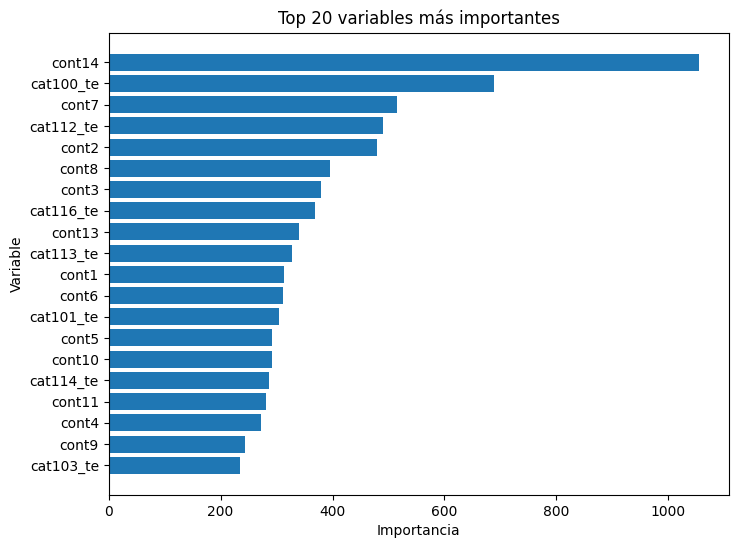

In [27]:
top_imp = importancias.head(20).sort_values("importancia")

plt.figure(figsize=(8,6))
plt.barh(top_imp["variable"], top_imp["importancia"])
plt.title("Top 20 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

# 📌 Conclusiones del modelamiento

- Se entrenó un modelo baseline lineal regularizado y un modelo basado en boosting para predecir la severidad de siniestros.
- El modelo más flexible permite capturar mejor relaciones no lineales y obtener una mejora respecto al baseline.
- La evaluación se realizó tanto en escala logarítmica como en escala original, permitiendo una lectura más técnica y también más cercana al negocio.
- El análisis de importancia de variables entrega primeras señales sobre los drivers más relevantes de severidad.

## ➡️ Siguiente paso

Utilizar las predicciones del mejor modelo para construir simulaciones de pricing y evaluar su impacto sobre métricas de rentabilidad del portafolio.